In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('superstore_data.csv', encoding = 'latin1')
print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Year'] = df['Order Date'].dt.to_period('M')

print(df.shape)
print(df.head())
print(df.info())

(9994, 24)
   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1       2  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2       3  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3       4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4       5  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

          Category  Sub-Category  \
0        Furniture     Bookcases   
1        Furniture   

In [8]:
# Category wise analysis
category_revenue = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False).reset_index()
print(category_revenue)

          Category        Sales       Profit
0       Technology  836154.0330  145454.9481
1        Furniture  741999.7953   18451.2728
2  Office Supplies  719047.0320  122490.8008


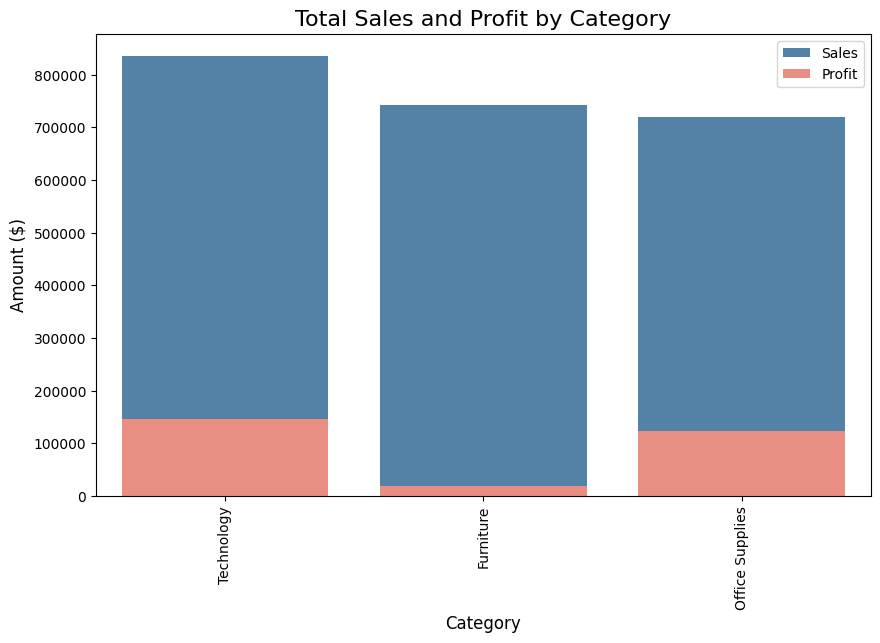

In [9]:
# Chart for category wise sales and profit
plt.figure(figsize=(10,6))
sns.barplot(x='Category', y='Sales', data=category_revenue, color='steelblue', label='Sales')
sns.barplot(x='Category', y='Profit', data=category_revenue, color='salmon', label='Profit')
plt.title('Total Sales and Profit by Category', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Amount ($)', fontsize=12)
plt.xticks(rotation=90)
plt.legend()
plt.show()


## Sales and Profit Analysis by Category

Based on the analysis we can conclude that higher revenue generated
by a category does not necessarily lead to higher profit.

- **Technology** has the highest revenue generation and also maintains
  the highest profit among all categories, successfully maintaining
  strong profitability.

- **Furniture** is the second highest revenue generating category
  but has the lowest profit generation compared to **Office Supplies**,
  which despite having lower revenue than Furniture, generates
  higher profit than it.

- This indicates potential issues with discount levels, shipping costs
  and marketing and pricing strategy in the Furniture category,
  making it an important category for further analysis.

In [10]:
subcategory_revenue = df.groupby(['Category', 'Sub-Category'])[['Sales', 'Profit']].sum().sort_values(by=['Category','Profit'], ascending=[True,True]).reset_index()
print(subcategory_revenue)

           Category Sub-Category        Sales      Profit
0         Furniture       Tables  206965.5320 -17725.4811
1         Furniture    Bookcases  114879.9963  -3472.5560
2         Furniture  Furnishings   91705.1640  13059.1436
3         Furniture       Chairs  328449.1030  26590.1663
4   Office Supplies     Supplies   46673.5380  -1189.0995
5   Office Supplies    Fasteners    3024.2800    949.5182
6   Office Supplies       Labels   12486.3120   5546.2540
7   Office Supplies          Art   27118.7920   6527.7870
8   Office Supplies    Envelopes   16476.4020   6964.1767
9   Office Supplies   Appliances  107532.1610  18138.0054
10  Office Supplies      Storage  223843.6080  21278.8264
11  Office Supplies      Binders  203412.7330  30221.7633
12  Office Supplies        Paper   78479.2060  34053.5693
13       Technology     Machines  189238.6310   3384.7569
14       Technology  Accessories  167380.3180  41936.6357
15       Technology       Phones  330007.0540  44515.7306
16       Techn

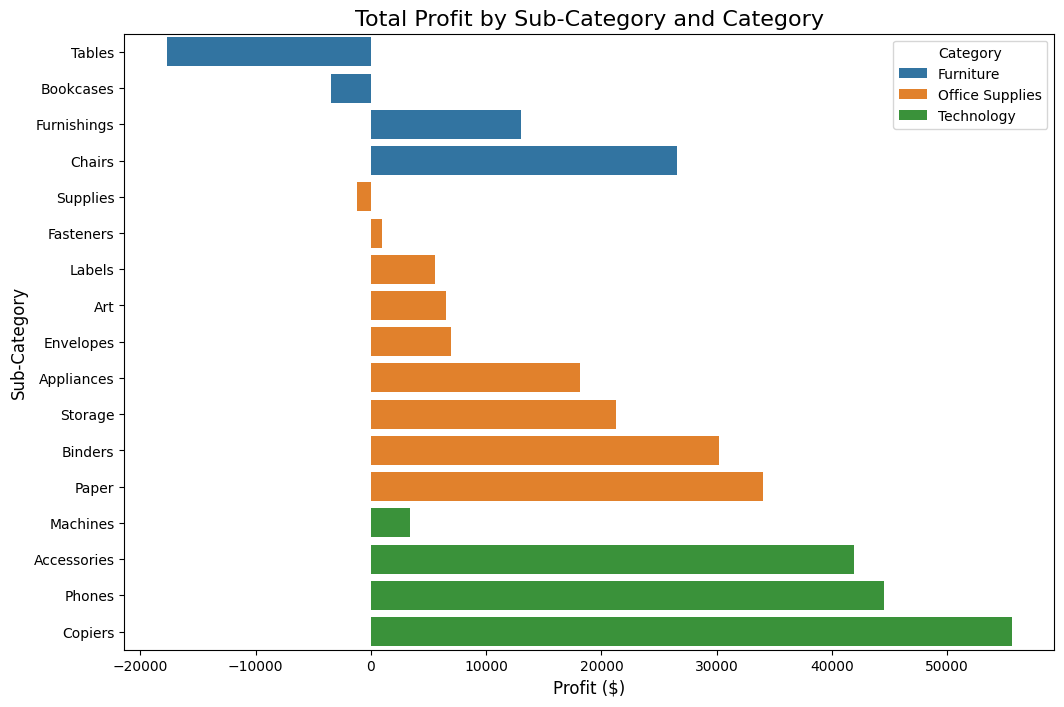

In [11]:
# Chart for sub-category wise sales and profit
subcategory_revenue_reset = subcategory_revenue.reset_index()

plt.figure(figsize=(12,8))
sns.barplot(
    data = subcategory_revenue_reset,
    x ='Profit',
    y = 'Sub-Category',
    hue = 'Category',
)

plt.title('Total Profit by Sub-Category and Category', fontsize=16)
plt.xlabel('Profit ($)', fontsize=12)
plt.ylabel('Sub-Category', fontsize=12)
plt.legend(title='Category')
plt.show()

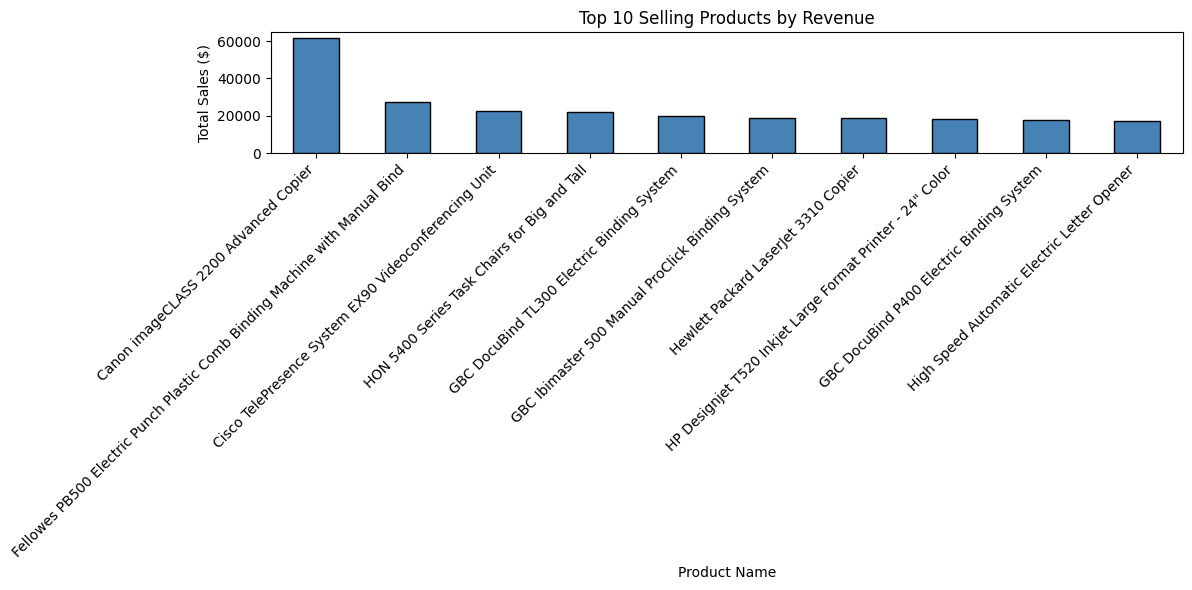

In [32]:
top_products = df.groupby('Product Name')['Sales'].sum()\
                 .sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
top_products.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Top 10 Selling Products by Revenue')
plt.xlabel('Product Name')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Sales and Profit Analysis by Sub-Category

Based on the sub-category analysis, the low profit ratio for the
**Furniture** category is primarily driven by **Tables** and **Bookcases**,
both of which are generating negative profit for the category.

- **Tables** are generating the highest negative profit even in
  comparison to Bookcases, which heavily impacts the overall profit
  ratio for the Furniture category. Possible reasons include issues
  with margins, discount levels, shipping costs, pricing strategy
  and marketing strategy.

- The **Technology** category is performing very strongly in profit
  generation with **Phones, Copiers and Accessories** being the top 3
  profit generating sub-categories, to be precise with the information **Copiers** are the highest selled products overtime. However **Machines** are generating
  the lowest profit compared to other sub-categories in this category,
  which requires further analysis before drawing any conclusion.

- For **Office Supplies**, only the **Supplies** sub-category is generating
  a very small portion of negative profit. The majority of profit for
  this category is coming from **Paper, Binders and Storage** sub-categories.

In [12]:
# Further analysis to find out affecting factors for the lose done by tables and bookcases
loss_df = df[df['Sub-Category'].isin(['Tables', 'Bookcases']) & (df['Profit'] < 0)]

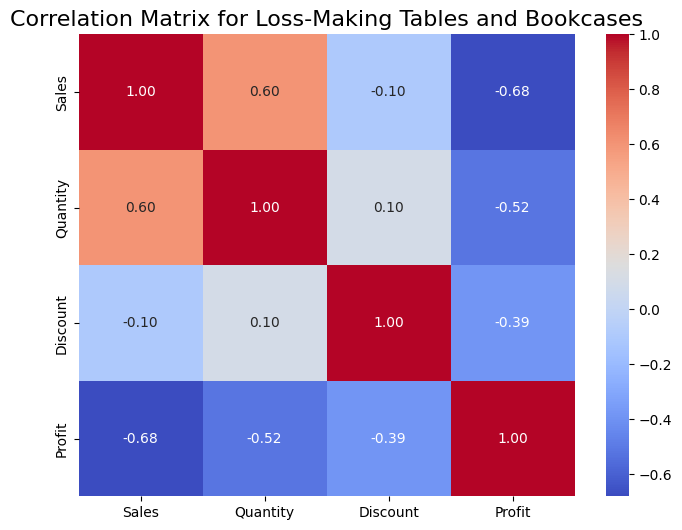

In [13]:
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']

corr_matrix = loss_df[num_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Loss-Making Tables and Bookcases', fontsize=16)
plt.show()

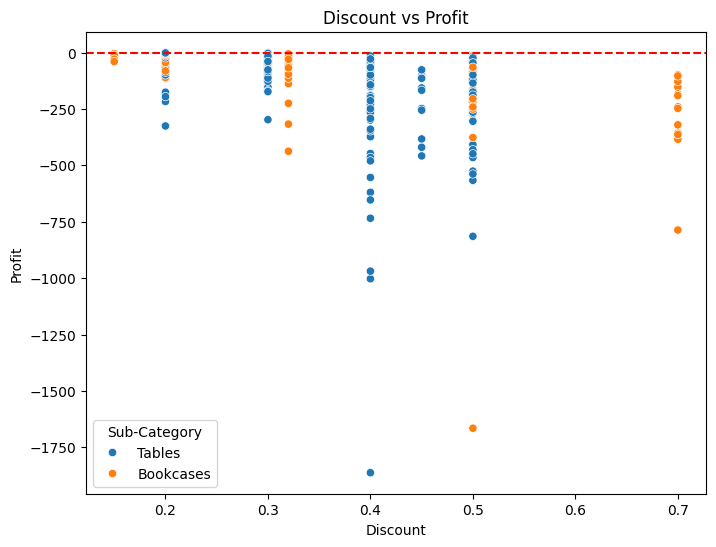

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=loss_df,
    x='Discount',
    y='Profit',
    hue='Sub-Category'
)

plt.title('Discount vs Profit')
plt.axhline(0, color='red', linestyle='--')

plt.show()

In [35]:
# Ship Mode analysis for Tables and Bookcases
furniture_loss = df[df['Sub-Category'].isin(['Tables', 'Bookcases'])]

# Sales and Profit by Ship Mode
shipmode_analysis = furniture_loss.groupby('Ship Mode').agg(
    Total_Sales    = ('Sales', 'sum'),
    Total_Profit   = ('Profit', 'sum'),
    Total_Orders   = ('Order ID', 'count'),
    Avg_Discount   = ('Discount', 'mean')
).round(2)

print(shipmode_analysis)

                Total_Sales  Total_Profit  Total_Orders  Avg_Discount
Ship Mode                                                            
First Class        49866.09      -1671.36            96          0.23
Same Day           12614.93       -736.86            28          0.23
Second Class       66000.96      -4348.70           109          0.23
Standard Class    193363.54     -14441.12           314          0.25


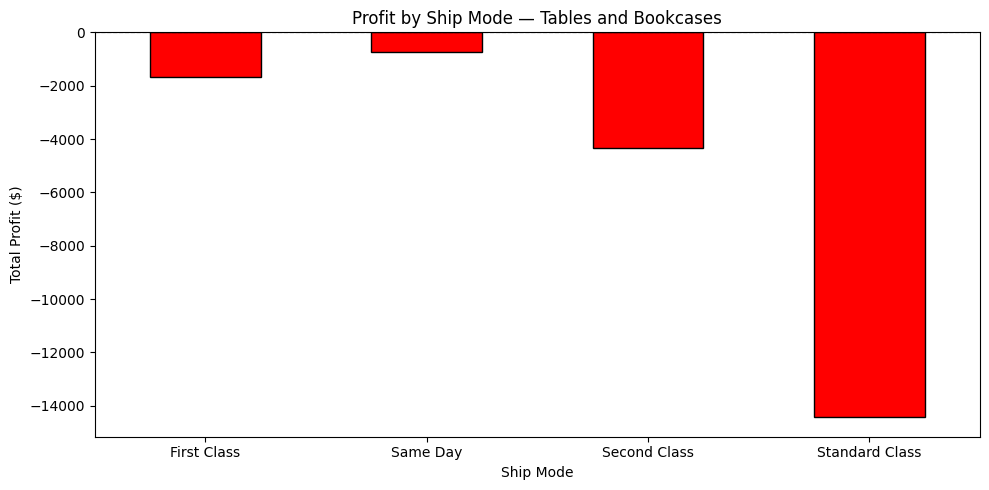

In [36]:
# Visualize Ship Mode vs Profit for Tables and Bookcases
plt.figure(figsize=(10, 5))
colors = ['green' if x > 0 else 'red' for x in shipmode_analysis['Total_Profit']]
shipmode_analysis['Total_Profit'].plot(kind='bar', color=colors, edgecolor='black')
plt.title('Profit by Ship Mode — Tables and Bookcases')
plt.xlabel('Ship Mode')
plt.ylabel('Total Profit ($)')
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Deep Dive Analysis — Tables and Bookcases

Analysis of loss-making Tables and Bookcases reveals that higher
discounts, larger order quantities and increased sales volume are
all associated with declining profitability.

### Key Observations

- **Profit vs Sales (-0.68)** — Strong negative correlation indicating
  that higher sales do not guarantee profitability for these sub-categories.

- **Profit vs Quantity (-0.52)** — Quantity negatively impacts profit,
  suggesting that bulk orders are contributing to larger losses
  rather than economies of scale.

- **Profit vs Discount (-0.39)** — Moderate negative correlation
  confirming that aggressive discounting is significantly
  reducing profit margins.

- **Tables vs Bookcases** — Tables generate more severe losses
  compared to Bookcases, particularly at discount levels
  between **40% and 50%**.

- The shipping method analysis for **Tables and Bookcases** reveals a clear
pattern — as the shipping quality improves, the profit becomes more negative.

This confirms that Tables and Bookcases are likely fragile products that
require premium shipping handling, and the higher cost associated with
better shipping methods is significantly eating into the profit margins,
further contributing to the overall loss in the Furniture category.

### Key Takeaway
> Current pricing and discount strategies for Furniture products
> are unsustainable and require immediate optimization to
> prevent continued profit erosion in this category.

In [15]:
# Region wise anaylysis
region_revenue = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values(by='Sales', ascending=False).reset_index()
region_revenue['ArithmeticError (%)'] = (region_revenue['Profit'] / region_revenue['Sales']) * 100
print(region_revenue)

    Region        Sales       Profit  ArithmeticError (%)
0     West  725457.8245  108418.4489            14.944831
1     East  678781.2400   91522.7800            13.483399
2  Central  501239.8908   39706.3625             7.921629
3    South  391721.9050   46749.4303            11.934342


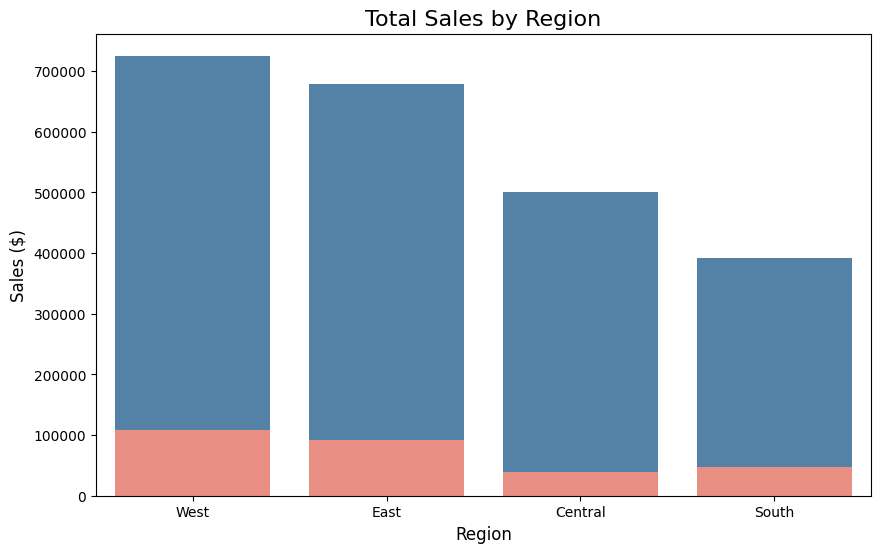

In [16]:
# Chart for region wise Sales
plt.figure(figsize=(10,6))
sns.barplot(x='Region', y='Sales', data=region_revenue, color='steelblue')
sns.barplot(x='Region', y='Profit', data=region_revenue, color='salmon')
plt.title('Total Sales by Region', fontsize=16) 
plt.xlabel('Region', fontsize=12)
plt.ylabel('Sales ($)', fontsize=12)
plt.xticks(rotation=0)
plt.show()

## Region Wise Sales and Profit Analysis

- **West** region performs the best in both sales and profit,
  maintaining the highest numbers across both metrics.

- **East** region follows closely behind West, maintaining
  a strong margin of high profit and high sales generation.

- **South** region has the lowest sales among all regions but
  its profit margin is higher compared to the Central region,
  suggesting that sales volume alone does not determine
  profit and business efficiency.

- **Central** region is the least efficient region business wise,
  generating the lowest profit despite having higher sales
  than the South region, indicating deeper issues with
  costs, discounts or pricing strategy in this region.

In [17]:
discount_summery =df.groupby('Discount').agg(
    Avg_Sales = ('Sales', 'mean'),
    Avg_Profit = ('Profit', 'mean'),
    Total_Profit = ('Profit', 'sum'),
    Orders = ('Order ID', 'count')
).sort_index()
print(discount_summery)

           Avg_Sales  Avg_Profit  Total_Profit  Orders
Discount                                              
0.00      226.742074   66.900292   320987.6032    4798
0.10      578.397351   96.055074     9029.1770      94
0.15      529.971567   27.288298     1418.9915      52
0.20      209.076940   24.702572    90337.3060    3657
0.30      454.742974  -45.679636   -10369.2774     227
0.32      536.794770  -88.560656    -2391.1377      27
0.40      565.134874 -111.927429   -23057.0504     206
0.45      498.634000 -226.646464    -2493.1111      11
0.50      892.705152 -310.703456   -20506.4281      66
0.60       48.150000  -43.077212    -5944.6552     138
0.70       97.177708  -95.874060   -40075.3569     418
0.80       56.545853 -101.796797   -30539.0392     300


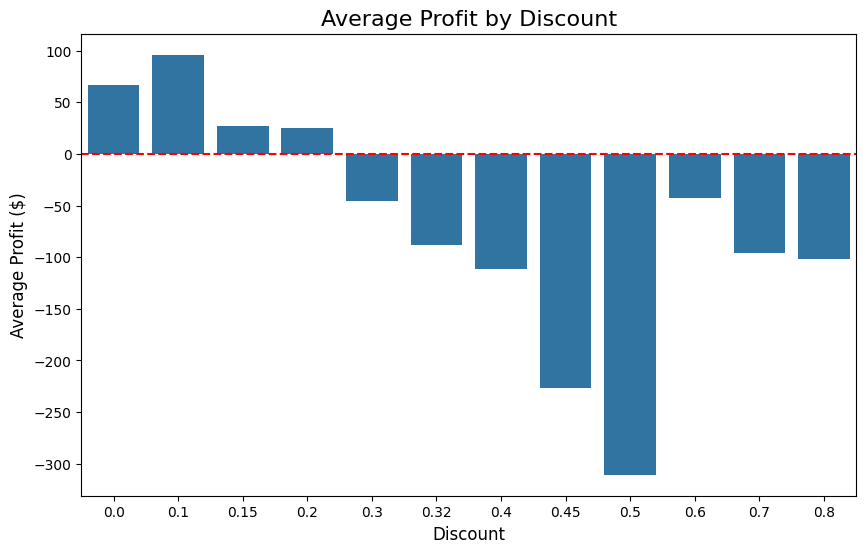

In [18]:
# Chart for average profit by discount
plt.figure(figsize=(10,6))
sns.barplot(
    data= discount_summery.reset_index(),
    x='Discount',
    y='Avg_Profit',
)

plt.axhline(0, color='red', linestyle='--')
plt.title('Average Profit by Discount', fontsize=16)
plt.xlabel('Discount', fontsize=12)
plt.ylabel('Average Profit ($)', fontsize=12)
plt.show()


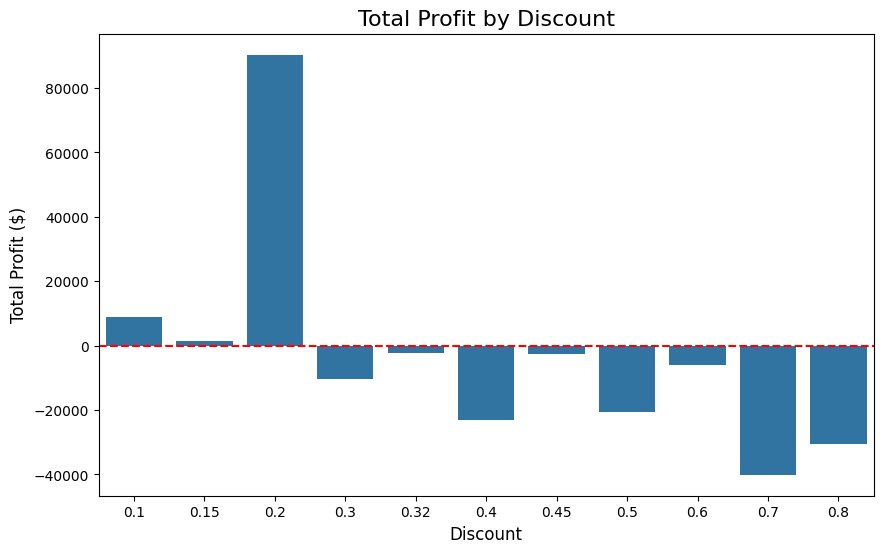

In [19]:
# Chart for total profit by discount
Discount_summery_without_zero = discount_summery[discount_summery.index > 0]
plt.figure(figsize=(10,6))
sns.barplot(
    data= Discount_summery_without_zero.reset_index(),  
    x='Discount',
    y='Total_Profit',
)
plt.axhline(0, color='red', linestyle='--')
plt.title('Total Profit by Discount', fontsize=16)  
plt.xlabel('Discount', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)
plt.show()

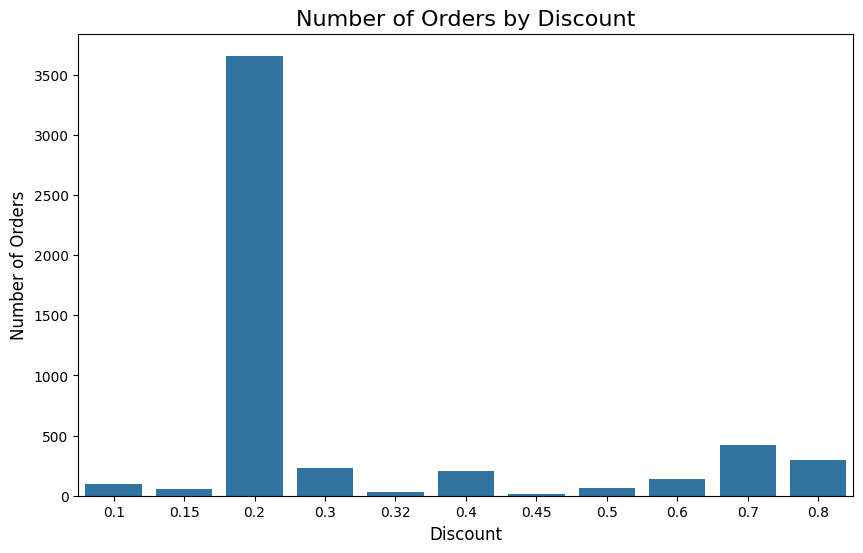

In [20]:
# chart for orders by discount
plt.figure(figsize=(10,6))
sns.barplot(
    data= Discount_summery_without_zero.reset_index(),
    x='Discount',
    y='Orders',
)

plt.title('Number of Orders by Discount', fontsize=16)
plt.xlabel('Discount', fontsize=12)
plt.ylabel('Number of Orders', fontsize=12)
plt.show()

## Discount Impact Analysis

Since orders without discounts generate significantly higher total profit, they were excluded from this chart to better visualize the impact of discount levels on profitability.

## Key Findings

- **20% Discount Level** emerges as the most sustainable promotional discount, balancing strong sales volume with acceptable profit margins compared to other discount tiers.

- **Discounts Exceeding 20%** show a sharp decline in profitability. Discount levels from 30% onwards consistently generate negative average profits, with the 70-80% range producing the highest absolute losses relative to order volume.

- **Zero Discount Orders** remain the most profitable strategy, generating the highest number of orders and total profit across all discount levels, demonstrating strong customer demand for full-price offerings.

### Recommendation

The current discount strategy requires optimization. The data suggests:
- Prioritize 0% and 10% discount offerings to maximize profitability
- Consider 20% as the maximum promotional discount to maintain sustainable margins
- Eliminate or severely restrict discounts exceeding 30%, as they consistently erode profits despite increased order volumes

In [25]:
monthly_trends = df.groupby('Month Year')[['Sales','Profit']].sum()
monthly_trends.index = monthly_trends.index.astype(str)

monthly_trends.head()

,Sales,Profit
Month Year,,
2014-01,14236.895,2450.1907
2014-02,4519.892,862.3084
2014-03,55691.009,498.7299
2014-04,28295.345,3488.8352
2014-05,23648.287,2738.7096


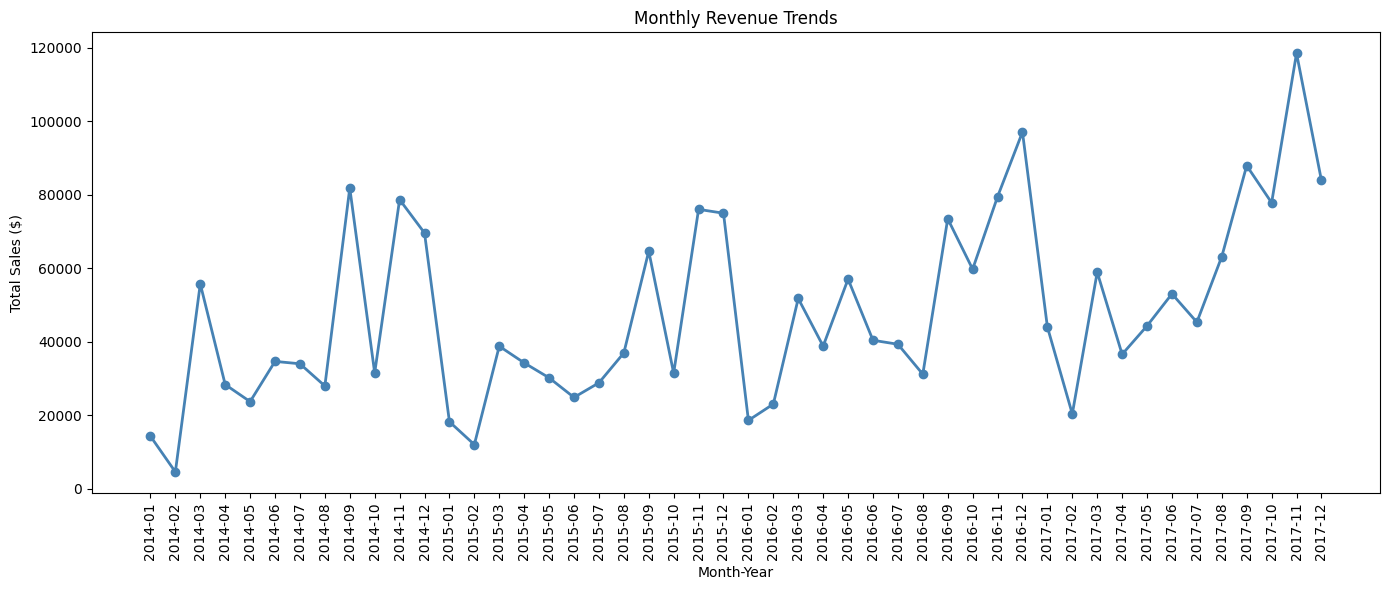

In [26]:
#Monthly sales trend analysis
monthly_revenue = df.groupby('Month Year')['Sales'].sum().reset_index()
monthly_revenue['Month Year'] = monthly_revenue['Month Year'].astype(str)

plt.figure(figsize=(14, 6))
plt.plot(monthly_revenue['Month Year'], monthly_revenue['Sales'], 
         marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Revenue Trends')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

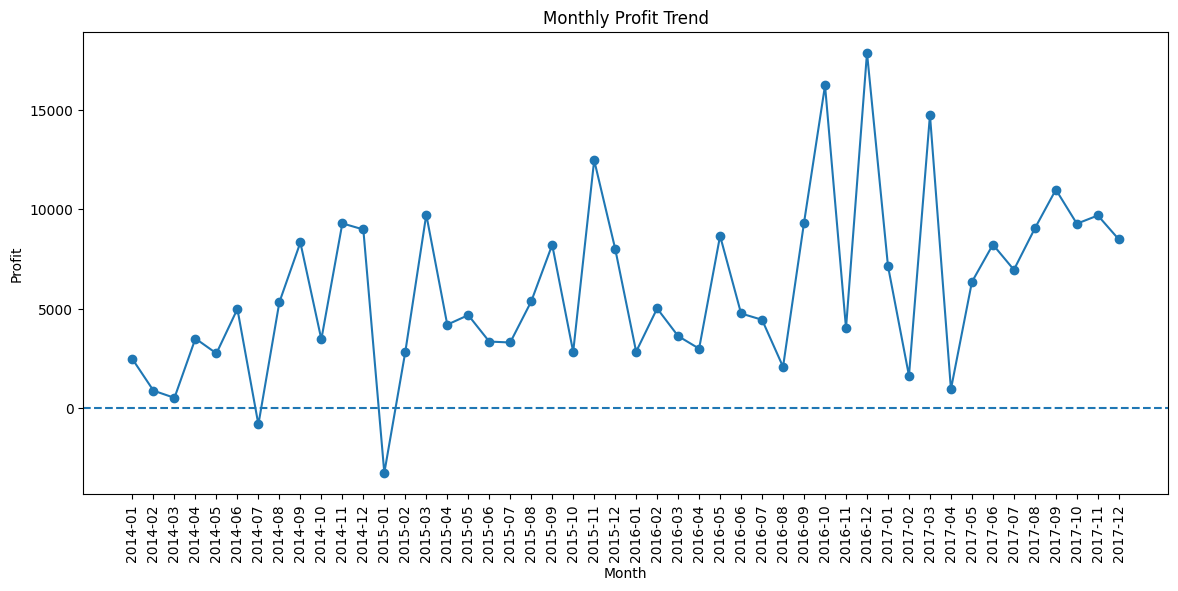

In [27]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_trends.index, monthly_trends['Profit'], marker='o'
)

plt.axhline(0, linestyle='--')

plt.title('Monthly Profit Trend')
plt.xlabel('Month')
plt.ylabel('Profit')
plt.xticks(rotation=90)
plt.show()

In [ ]:
yearly_trends = df.groupby('Year')[['Sales', 'Profit']].sum()


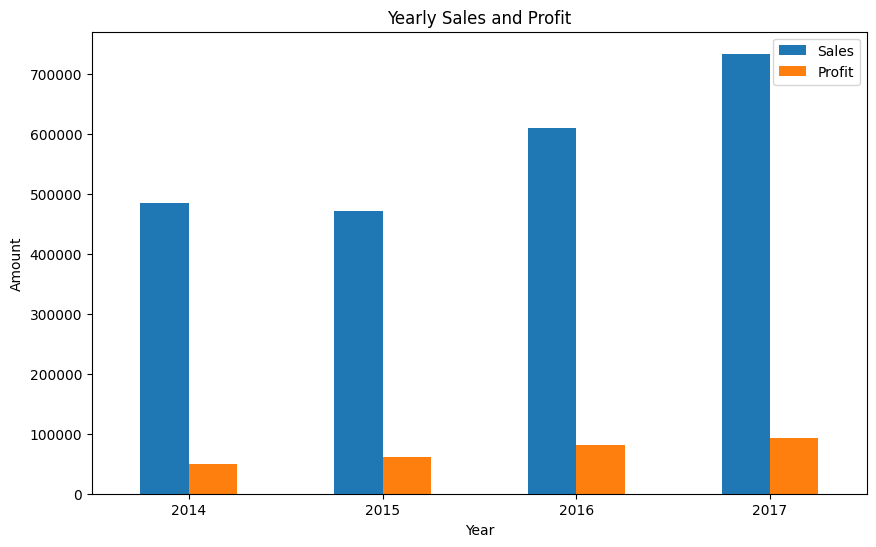

In [30]:
yearly_trends.plot(kind='bar', figsize=(10,6))

plt.title('Yearly Sales and Profit')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()


## Yearly and Monthly Revenue Trend Analysis

### Yearly Analysis
Superstore sales generally increased from **2014 to 2017** with only
a slight decline in sales during **2015**. Profit however increased
consistently every year including 2015, indicating positive business
development and improving profitability over time.

### Monthly Trends
Sales consistently reach higher levels toward the end of the year,
particularly from **September to December**, which is likely driven
by seasonal demand and increased shopping activity during
the holiday period.

### Profit Volatility
While profit shows an overall positive trend, monthly profit is
more volatile compared to sales. Some months show sharp increases
while a few periods even record negative profit.

Notable profit peaks in **late 2016** and **March 2017** stand out
and may require further analysis to understand which categories,
regions or discount levels contributed to these unusual spikes.

### Key Takeaway
> Despite occasional volatility, the overall business trajectory
> is positive with both sales and profit showing consistent
> growth from 2014 to 2017. Seasonal patterns and profit
> anomalies in specific months warrant deeper investigation
> for better business planning.

In [34]:
df.to_csv('superstore_cleaned.csv', index=False)
print("Saved successfully!")

Saved successfully!
